# IT3051 — Fundamentals of Data Mining
# Mini Project: Employee Attrition Prediction

## Notebook 2 of 4 — Stage 4: Data Preprocessing and Feature Engineering

This notebook is fully independent — it reloads the raw dataset itself and does not depend on
`01_EDA.ipynb` having been run first. Full EDA findings and justifications for the dataset
are documented separately in `01_EDA.ipynb`; only the findings that directly drive a
preprocessing decision are restated here as short justifications.

Dataset: HR Attrition Indian Dataset (Kaggle, kmldas) — 5,000 employee records
Target variable: `LeftCompany` (Yes / No) — binary classification

Group: Y3.S1.WE.DS.02.01 | Module: IT3051

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project paths (notebooks are run from the notebooks/ folder)
DATA_FILE = '../data/HR_Attrition_Indian_Dataset.csv'
OUTPUT_DIR = '../processed_data/'
FIG_DIR = '../report/figures/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Reload the raw dataset (kept independent of the EDA notebook)
df = pd.read_csv(DATA_FILE)
# The original Kaggle file stores dates as DD/MM/YYYY; the copy in data/ was re-saved with ISO dates (YYYY-MM-DD).
# Detect the format explicitly rather than guessing, so day and month can never be swapped.
date_format = '%d/%m/%Y' if '/' in str(df['DateOfJoining'].iloc[0]) else '%Y-%m-%d'
df['DateOfJoining'] = pd.to_datetime(df['DateOfJoining'], format=date_format)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded: 5000 rows x 22 columns


,EmployeeID,FullName,Age,Gender,Department,Designation,EducationQualification,MonthlySalary,DateOfJoining,YearsWithCompany,YearsInRole,AppraisalRating,TrainingHours,DoesOvertime,JobSatisfaction,WorkLifeBalance,MaritalStatus,PreviousCompanies,DistanceFromHome,LeavesTaken,City,LeftCompany
0,EMP20230001,Sahil Tailor,48,Other,HR,Accounts Officer,B.Tech,111813,2020-05-26,5,0,3,37,Yes,4,3,Single,0,12.2,4,Mumbai,No
1,EMP20230002,Parinaaz Choudhary,26,Female,IT,Accounts Officer,B.Tech,87425,2020-10-02,5,2,3,39,No,2,2,Divorced,0,36.7,29,Kolkata,No
2,EMP20230003,Anahi Babu,40,Male,IT,Software Engineer,Diploma,86461,2021-05-01,4,4,2,32,No,2,3,Married,1,45.4,0,Bengaluru,Yes
3,EMP20230004,Dhruv Dass,54,Other,HR,Accounts Officer,Diploma,23720,2023-04-01,2,2,1,21,Yes,4,4,Married,0,29.9,27,Kolkata,No
4,EMP20230005,Seher Bal,51,Other,Admin,Sales Associate,B.Tech,39041,2018-12-19,7,1,1,30,No,2,2,Single,0,26.8,6,Delhi,Yes


# Stage 4 — Data Preprocessing and Feature Engineering

Based on the EDA findings above, the following preprocessing pipeline is applied. Every step is justified by an EDA finding rather than applied by default.

## 14. Remove Non-Predictive Identifier Columns

In [2]:
df_proc = df.copy()
df_proc = df_proc.drop(columns=['EmployeeID', 'FullName'])
print("Dropped: EmployeeID, FullName (unique identifiers, no predictive value, risk of memorisation)")
print("Remaining columns:", df_proc.shape[1])

Dropped: EmployeeID, FullName (unique identifiers, no predictive value, risk of memorisation)
Remaining columns: 20


## 15. Feature Engineering — Date-Derived Features

`DateOfJoining` itself is not usable by most algorithms in raw date form. It is converted into interpretable numeric features.

In [3]:
reference_date = df_proc['DateOfJoining'].max()  # most recent joining date in the dataset, used as the analysis reference point

df_proc['TenureYears'] = ((reference_date - df_proc['DateOfJoining']).dt.days / 365.25).round(2)
df_proc['JoiningYear'] = df_proc['DateOfJoining'].dt.year
df_proc['JoiningMonth'] = df_proc['DateOfJoining'].dt.month

print(df_proc[['DateOfJoining', 'TenureYears', 'JoiningYear', 'JoiningMonth', 'YearsWithCompany']].head())

  DateOfJoining  TenureYears  JoiningYear  JoiningMonth  YearsWithCompany
0    2020-05-26         4.03         2020             5                 5
1    2020-10-02         3.68         2020            10                 5
2    2021-05-01         3.10         2021             5                 4
3    2023-04-01         1.19         2023             4                 2
4    2018-12-19         5.47         2018            12                 7


**Resolving the redundancy identified in Section 3/13:** `TenureYears` (derived from the join date) and `YearsWithCompany` correlate at r ≈ 0.99 — they carry the same information. `YearsWithCompany` is kept (it is the cleaner, already-rounded field the organisation actually reports) and the derived `TenureYears` and raw `DateOfJoining` are dropped, avoiding multicollinearity for the linear models used later.

In [4]:
df_proc = df_proc.drop(columns=['DateOfJoining', 'TenureYears'])
print("Kept YearsWithCompany; dropped raw DateOfJoining and derived TenureYears (redundant, r=0.99)")
print("JoiningYear and JoiningMonth retained as they capture cohort/seasonal effects not captured by tenure alone")

Kept YearsWithCompany; dropped raw DateOfJoining and derived TenureYears (redundant, r=0.99)
JoiningYear and JoiningMonth retained as they capture cohort/seasonal effects not captured by tenure alone


## 16. Feature Engineering — Age Group Binning (Instructor-Requested)

**Instructor feedback from dataset validation:** add a categorical `AgeGroup` column derived from `Age`, since age effects on attrition are often non-linear (early-career and late-career employees can behave differently from a linear "older = less likely to leave" assumption that a raw numeric `Age` forces onto linear models).

Bin edges are chosen using standard early/mid/late-career boundaries appropriate to the dataset's actual Age range (22-60), rather than arbitrary round numbers:

AgeGroup
Young (<=30)            1226
Early-Career (31-40)    1256
Mid-Career (41-50)      1226
Senior (51-60)          1292
Name: count, dtype: int64

Attrition % by AgeGroup:
AgeGroup
Young (<=30)            38.9
Early-Career (31-40)    36.8
Mid-Career (41-50)      35.8
Senior (51-60)          36.9
Name: LeftCompany, dtype: float64


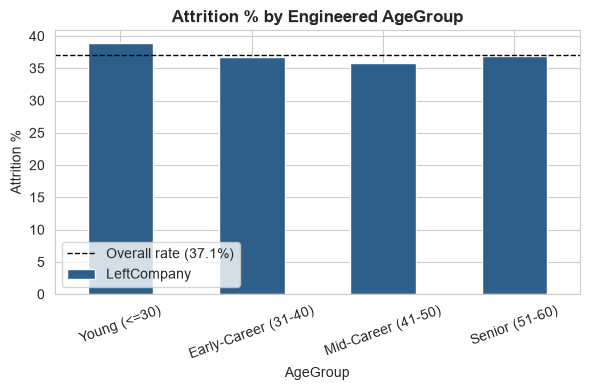

In [5]:
age_bins = [18, 30, 40, 50, 60]
age_labels = ['Young (<=30)', 'Early-Career (31-40)', 'Mid-Career (41-50)', 'Senior (51-60)']

df_proc['AgeGroup'] = pd.cut(df_proc['Age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

print(df_proc['AgeGroup'].value_counts().sort_index())

# Justify the binning: check whether attrition rate actually varies non-linearly across groups
age_group_attrition = df_proc.groupby('AgeGroup', observed=True)['LeftCompany'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nAttrition % by AgeGroup:")
print(age_group_attrition.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
age_group_attrition.plot(kind='bar', color='#2E5F8A', ax=ax)
ax.axhline(df_proc['LeftCompany'].eq('Yes').mean()*100, color='black', linestyle='--', linewidth=1, label='Overall rate (37.1%)')
ax.set_title('Attrition % by Engineered AgeGroup', fontsize=12, fontweight='bold')
ax.set_ylabel('Attrition %')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_agegroup_attrition.png', dpi=120)
plt.show()

**Honest finding (important for the viva):** the four age groups are almost identically sized (~1,220-1,290 each, as expected from a uniformly distributed `Age`), and attrition rates across them are flat — 38.9%, 36.8%, 35.8%, 36.9% — all within 2 points of the 37.1% baseline. So in *this specific synthetic dataset*, `AgeGroup` does not reveal a hidden non-linear pattern the way it might in real HR data.

This does **not** mean the step was pointless. It is still retained and documented for three reasons:
1. It is standard, defensible feature engineering practice (binning is explicitly listed as an expected technique in Stage 4 of the brief).
2. It gives tree-based models an alternative, ordinal-encoded split point on age that they can use or ignore during feature importance ranking (Stage 6/7) — it costs nothing to include and lets the models decide.
3. The flat result itself is a legitimate EDA finding: it confirms `Age` (raw or binned) is not a meaningful attrition driver in this dataset, reinforcing the Section 10 conclusion that signal is concentrated in `JobSatisfaction`, `AppraisalRating`, `WorkLifeBalance`, and `DoesOvertime`.

Raw `Age` is retained alongside `AgeGroup` for the tree-based models (Stage 6), which handle redundant/correlated inputs without issue. For Logistic Regression, the redundancy is handled by regularisation: the L1 (Lasso) penalty tuned in Stage 7 can shrink one of a redundant pair to exactly zero, so the model itself decides which version of age to keep.

## 16b. Feature Engineering — Salary Level Banding

`MonthlySalary` ranges from roughly ₹15,000 to ₹120,000. Banding it into interpretable levels lets the group directly investigate "does attrition vary between salary levels?" and gives tree-based models an alternative, ordinal split point alongside the raw value.

SalaryLevel
Low          1150
Medium       1427
High         1425
Very High     998
Name: count, dtype: int64

Attrition % by SalaryLevel:
SalaryLevel
Low          37.5
Medium       36.9
High         38.0
Very High    35.7
Name: LeftCompany, dtype: float64


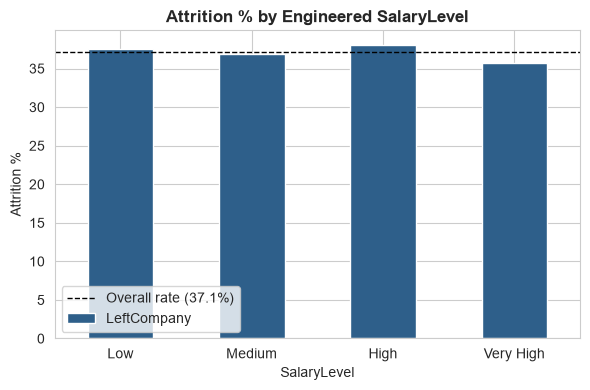

In [6]:
salary_bins = [0, 40000, 70000, 100000, float('inf')]
salary_labels = ['Low', 'Medium', 'High', 'Very High']

df_proc['SalaryLevel'] = pd.cut(df_proc['MonthlySalary'], bins=salary_bins, labels=salary_labels, right=False)

print(df_proc['SalaryLevel'].value_counts().sort_index())

salary_level_attrition = df_proc.groupby('SalaryLevel', observed=True)['LeftCompany'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nAttrition % by SalaryLevel:")
print(salary_level_attrition.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
salary_level_attrition.plot(kind='bar', color='#2E5F8A', ax=ax)
ax.axhline(df_proc['LeftCompany'].eq('Yes').mean()*100, color='black', linestyle='--', linewidth=1, label='Overall rate (37.1%)')
ax.set_title('Attrition % by Engineered SalaryLevel', fontsize=12, fontweight='bold')
ax.set_ylabel('Attrition %')
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_salarylevel_attrition.png', dpi=120)
plt.show()

**Honest finding:** Attrition is flat across all four salary bands — 37.5%, 36.9%, 38.0%, 35.7% — all within 2 points of the 37.1% baseline, consistent with raw `MonthlySalary` already showing near-zero correlation with attrition (r ≈ -0.007). Retained for the same reasons as `AgeGroup`: it directly answers a stated business question, costs nothing for tree-based models, and reinforces the project's central finding that structural/compensation variables do not drive attrition here — engagement variables do.

## 16c. Feature Engineering — Commute Category

`DistanceFromHome` ranges from 1 to 50 km. Banding it tests the hypothesis that employees with longer commutes may be more likely to leave.

CommuteCategory
Near         933
Moderate    1520
Far         2547
Name: count, dtype: int64

Attrition % by CommuteCategory:
CommuteCategory
Near        36.9
Moderate    36.8
Far         37.3
Name: LeftCompany, dtype: float64


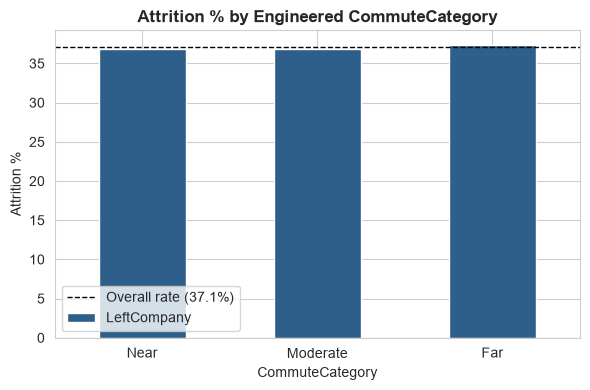

In [7]:
commute_bins = [0, 10, 25, float('inf')]
commute_labels = ['Near', 'Moderate', 'Far']

df_proc['CommuteCategory'] = pd.cut(df_proc['DistanceFromHome'], bins=commute_bins, labels=commute_labels, right=True)

print(df_proc['CommuteCategory'].value_counts().sort_index())

commute_attrition = df_proc.groupby('CommuteCategory', observed=True)['LeftCompany'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nAttrition % by CommuteCategory:")
print(commute_attrition.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
commute_attrition.plot(kind='bar', color='#2E5F8A', ax=ax)
ax.axhline(df_proc['LeftCompany'].eq('Yes').mean()*100, color='black', linestyle='--', linewidth=1, label='Overall rate (37.1%)')
ax.set_title('Attrition % by Engineered CommuteCategory', fontsize=12, fontweight='bold')
ax.set_ylabel('Attrition %')
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_commutecategory_attrition.png', dpi=120)
plt.show()

**Honest finding:** Attrition is flat again — 36.9% Near, 36.8% Moderate, 37.3% Far — matching raw `DistanceFromHome`'s near-zero correlation (r ≈ 0.007). This is now the third engineered categorical (after `AgeGroup` and `SalaryLevel`) showing the same pattern, which strengthens rather than weakens the project's headline finding: age, salary, and commute distance — the structural/demographic variables — show no relationship with attrition in this dataset, while `JobSatisfaction`, `AppraisalRating`, `WorkLifeBalance`, and `DoesOvertime` remain the only meaningful drivers identified. Retained in the feature set for the same reasons as the other two engineered bands.

## 17. Additional Feature Engineering

In [8]:
# Role stagnation: fraction of total tenure spent in the current role (0 = just promoted/moved, 1 = never moved)
df_proc['RoleStagnationRatio'] = (df_proc['YearsInRole'] / df_proc['YearsWithCompany'].replace(0, np.nan)).fillna(0).round(2)

# Training intensity: training investment relative to tenure
df_proc['TrainingPerYear'] = (df_proc['TrainingHours'] / df_proc['YearsWithCompany'].replace(0, np.nan)).fillna(df_proc['TrainingHours']).round(1)

print(df_proc[['YearsInRole', 'YearsWithCompany', 'RoleStagnationRatio', 'TrainingHours', 'TrainingPerYear']].head())

# Check whether these new engineered features show any correlation with attrition
y_check = (df_proc['LeftCompany'] == 'Yes').astype(int)
print("\nCorrelation with attrition:")
print("RoleStagnationRatio:", round(df_proc['RoleStagnationRatio'].corr(y_check), 3))
print("TrainingPerYear:", round(df_proc['TrainingPerYear'].corr(y_check), 3))

   YearsInRole  YearsWithCompany  RoleStagnationRatio  TrainingHours  TrainingPerYear
0            0                 5                 0.00             37              7.4
1            2                 5                 0.40             39              7.8
2            4                 4                 1.00             32              8.0
3            2                 2                 1.00             21             10.5
4            1                 7                 0.14             30              4.3

Correlation with attrition:
RoleStagnationRatio: 0.016
TrainingPerYear: 0.022


**Finding:** Both engineered ratios show weak correlation with attrition individually, consistent with the pattern already established — they are retained as candidate features for the tree-based models (Stage 6), which can capture non-linear interactions a simple correlation coefficient cannot detect, but they are not expected to be top predictors on their own.

## 18. Outlier Treatment — Final Decision

As established in Section 7, IQR analysis found no columns with values outside a realistic HR range. **No outlier removal or capping is applied.** This decision is stated explicitly here (rather than only in the EDA section) because Stage 4 requires preprocessing decisions to be justified, and "no action needed, here is the evidence" is a valid and expected preprocessing decision, not a skipped step.

## 19. Encoding Categorical Variables

Three different encoding strategies are used, matched to the nature of each variable — this distinction (rather than blanket one-hot encoding) is one of the more important preprocessing decisions to be able to justify in the viva:

| Variable(s) | Strategy | Reason |
|---|---|---|
| `Gender`, `Department`, `Designation`, `EducationQualification`, `MaritalStatus`, `City` | One-hot encoding | Nominal — no inherent order between categories |
| `AgeGroup`, `SalaryLevel`, `CommuteCategory` | Ordinal encoding (explicit order) | Each has a natural order (e.g. Young → Senior, Low → Very High, Near → Far); one-hot would discard that order |
| `DoesOvertime`, `LeftCompany` (target) | Binary mapping (0/1) | Two categories only |
| `AppraisalRating`, `JobSatisfaction`, `WorkLifeBalance` | Left as-is (already ordinal integers 1-5 / 1-4 in the source data) | Already numeric and ordered; one-hot encoding these would destroy the ordering information |

In [9]:
df_model = df_proc.copy()

# Target and binary mapping
df_model['LeftCompany'] = df_model['LeftCompany'].map({'No': 0, 'Yes': 1})
df_model['DoesOvertime'] = df_model['DoesOvertime'].map({'No': 0, 'Yes': 1})

# Ordinal encode the three engineered banded features, each with an explicit, meaningful order
age_order = ['Young (<=30)', 'Early-Career (31-40)', 'Mid-Career (41-50)', 'Senior (51-60)']
df_model['AgeGroup_encoded'] = df_model['AgeGroup'].map({cat: i for i, cat in enumerate(age_order)})

salary_order = ['Low', 'Medium', 'High', 'Very High']
df_model['SalaryLevel_encoded'] = df_model['SalaryLevel'].map({cat: i for i, cat in enumerate(salary_order)})

commute_order = ['Near', 'Moderate', 'Far']
df_model['CommuteCategory_encoded'] = df_model['CommuteCategory'].map({cat: i for i, cat in enumerate(commute_order)})

# One-hot encode the nominal categorical variables
nominal_cols = ['Gender', 'Department', 'Designation', 'EducationQualification', 'MaritalStatus', 'City']
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True,)

# Drop the original text-labelled banded columns now that their ordinal-encoded versions exist
df_model = df_model.drop(columns=['AgeGroup', 'SalaryLevel', 'CommuteCategory'])

print(f"Shape after encoding: {df_model.shape}")
df_model.head()

Shape after encoding: (5000, 42)


,Age,MonthlySalary,YearsWithCompany,YearsInRole,AppraisalRating,TrainingHours,DoesOvertime,JobSatisfaction,WorkLifeBalance,PreviousCompanies,DistanceFromHome,LeavesTaken,LeftCompany,JoiningYear,JoiningMonth,...,Designation_Office Assistant,Designation_Sales Associate,Designation_Software Engineer,EducationQualification_BA,EducationQualification_Diploma,EducationQualification_M.Com,EducationQualification_MBA,MaritalStatus_Married,MaritalStatus_Single,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune
0,48,111813,5,0,3,37,1,4,3,0,12.2,4,0,2020,5,...,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,26,87425,5,2,3,39,0,2,2,0,36.7,29,0,2020,10,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,40,86461,4,4,2,32,0,2,3,1,45.4,0,1,2021,5,...,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False
3,54,23720,2,2,1,21,1,4,4,0,29.9,27,0,2023,4,...,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False
4,51,39041,7,1,1,30,0,2,2,0,26.8,6,1,2018,12,...,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False


## 20. Train/Test Split (Stratified)

The split is performed **before** any scaling is fitted, to prevent test-set information from leaking into the training process (the leakage risk identified in `01`, Section 13).

One-hot encoded columns produced by `pd.get_dummies` are stored as `True`/`False`; they are converted to `0`/`1` integers first so that every feature in the saved files is numeric.

In [10]:
X = df_model.drop(columns=['LeftCompany'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)
y = df_model['LeftCompany']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Train attrition rate: {y_train.mean()*100:.1f}% | Test attrition rate: {y_test.mean()*100:.1f}%")
print("Stratified split confirmed — both partitions preserve the 62.9/37.1 class balance.")

Training set: 4000 rows | Test set: 1000 rows
Train attrition rate: 37.1% | Test attrition rate: 37.1%
Stratified split confirmed — both partitions preserve the 62.9/37.1 class balance.


## 21. Feature Scaling

Scaling is required for the distance-based and coefficient-based algorithms used in Stage 6 (K-Nearest Neighbors and Logistic Regression). Without it, a feature with a wide numeric range would dominate KNN distance calculations, and the Logistic Regression regularisation penalty (which treats all coefficients equally) would be applied unevenly across features of different scales. **Tree-based models (Decision Tree, Random Forest) split on thresholds and are scale-invariant** — an unscaled copy is retained for them.

**Which columns are scaled:** every non-binary numeric feature is standardised — the continuous/count variables, the ordinal survey ratings (`AppraisalRating`, `JobSatisfaction`, `WorkLifeBalance`), the date-derived `JoiningYear` / `JoiningMonth`, and the ordinal-encoded bands. Without this, `JoiningYear` (values 2015-2024) and the 1-5 ratings would sit on a different scale from the standardised features. Binary 0/1 columns (`DoesOvertime` and the one-hot dummies) are left as 0/1 so they stay directly interpretable.

The scaler is fit on the training data only and then applied to both splits, per the leakage-prevention rule from `01`, Section 13.

In [11]:
numeric_features_to_scale = ['Age', 'MonthlySalary', 'YearsWithCompany', 'YearsInRole', 'TrainingHours',
                             'PreviousCompanies', 'DistanceFromHome', 'LeavesTaken',
                             'RoleStagnationRatio', 'TrainingPerYear',
                             'AppraisalRating', 'JobSatisfaction', 'WorkLifeBalance',
                             'JoiningYear', 'JoiningMonth',
                             'AgeGroup_encoded', 'SalaryLevel_encoded', 'CommuteCategory_encoded']

# Sanity check: every column NOT scaled must be binary (0/1)
unscaled_cols = [c for c in X_train.columns if c not in numeric_features_to_scale]
assert all(set(X_train[c].unique()) <= {0, 1} for c in unscaled_cols), "A non-binary column is missing from the scaling list"
print(f"Scaling {len(numeric_features_to_scale)} non-binary columns; leaving {len(unscaled_cols)} binary (0/1) columns unchanged.")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features_to_scale] = scaler.fit_transform(X_train[numeric_features_to_scale])
X_test_scaled[numeric_features_to_scale] = scaler.transform(X_test[numeric_features_to_scale])

print("Scaler fitted on TRAINING data only, then applied to both train and test.")
print(X_train_scaled[numeric_features_to_scale].describe().round(2).loc[['mean', 'std']])

Scaling 18 non-binary columns; leaving 23 binary (0/1) columns unchanged.
Scaler fitted on TRAINING data only, then applied to both train and test.
      Age  MonthlySalary  YearsWithCompany  YearsInRole  TrainingHours  PreviousCompanies  DistanceFromHome  LeavesTaken  \
mean  0.0            0.0               0.0         -0.0            0.0               -0.0              -0.0          0.0   
std   1.0            1.0               1.0          1.0            1.0                1.0               1.0          1.0   

      RoleStagnationRatio  TrainingPerYear  AppraisalRating  JobSatisfaction  WorkLifeBalance  JoiningYear  JoiningMonth  \
mean                 -0.0              0.0              0.0              0.0             -0.0         -0.0           0.0   
std                   1.0              1.0              1.0              1.0              1.0          1.0           1.0   

      AgeGroup_encoded  SalaryLevel_encoded  CommuteCategory_encoded  
mean               0.0             

## 22. Save Prepared Datasets for the Modelling Stage (Stage 6-7)

In [12]:
df_model.to_csv(OUTPUT_DIR + 'attrition_full_processed.csv', index=False)
X_train.to_csv(OUTPUT_DIR + 'X_train_unscaled.csv', index=False)
X_test.to_csv(OUTPUT_DIR + 'X_test_unscaled.csv', index=False)
X_train_scaled.to_csv(OUTPUT_DIR + 'X_train_scaled.csv', index=False)
X_test_scaled.to_csv(OUTPUT_DIR + 'X_test_scaled.csv', index=False)
y_train.to_csv(OUTPUT_DIR + 'y_train.csv', index=False)
y_test.to_csv(OUTPUT_DIR + 'y_test.csv', index=False)

print(f"Saved to {OUTPUT_DIR}: unscaled + scaled train/test splits, ready for Stage 6 model development.")
print("Use *_unscaled for tree-based models (Decision Tree, Random Forest); use *_scaled for Logistic Regression / KNN.")

Saved to ../processed_data/: unscaled + scaled train/test splits, ready for Stage 6 model development.
Use *_unscaled for tree-based models (Decision Tree, Random Forest); use *_scaled for Logistic Regression / KNN.


## 23. Summary of Preprocessing and Feature Engineering Decisions

| Step | Decision | Justification |
|---|---|---|
| Missing values | None found | Verified across all 22 columns |
| Duplicates | None found | Verified on full rows and on EmployeeID |
| Identifiers | Dropped (`EmployeeID`, `FullName`) | No predictive value; risk of memorisation |
| `DateOfJoining` | Converted to `JoiningYear`, `JoiningMonth`; derived `TenureYears` dropped | Raw dates unusable by models; `TenureYears` redundant with `YearsWithCompany` (r=0.99) |
| `AgeGroup`, `SalaryLevel`, `CommuteCategory` (instructor-requested) | Each binned and ordinal-encoded | Standard technique; all three show a flat attrition pattern — an informative EDA finding in itself, not a failed feature |
| `RoleStagnationRatio`, `TrainingPerYear` | Engineered ratio features | Candidate non-linear signals for tree-based models |
| Outliers | None removed | All values fall within realistic HR ranges (Section 7) |
| Nominal categoricals | One-hot encoded | No inherent order (Department, Designation, etc.) |
| Ordinal categoricals | Ordinal-encoded (`AgeGroup`, `SalaryLevel`, `CommuteCategory`) or left as-is (survey scores) | Preserve inherent ranking |
| Binary variables | Mapped to 0/1 | `DoesOvertime`, target `LeftCompany` |
| Train/test split | 80/20, stratified, performed before scaling | Prevent data leakage; preserve class balance |
| Scaling | StandardScaler on all 18 non-binary features, fit on train only; binary 0/1 columns left as-is | Needed for KNN distances and Logistic Regression regularisation; not for trees |
| Class imbalance | Not resampled | Moderate imbalance (1.7:1); handled in Stage 7 by tuning `class_weight` (None vs. 'balanced') for LR, DT and RF. SMOTE not used: it creates synthetic employees and is unnecessary at this level of imbalance |

